# **Hospital Readmission Prediction & Patient Risk Intelligence System**

### 1. Import Libraries and Loading Dataset

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Healthforcast-Model/Diabetic_Processed_Data.csv")

| Library            | Purpose                         |
| ------------------ | ------------------------------- |
| train_test_split   | Split data                      |
| Pipeline           | Combine preprocessing and model |
| SimpleImputer      | Handle missing values           |
| LogisticRegression | Baseline model                  |
| RandomForest       | Ensemble model                  |
| XGBoost            | Boosting model                  |
| Metrics            | Evaluate performance            |


### 2. Seperate Fetures and Target

In [ ]:
X = df.drop('readmitted', axis=1)

y = df['readmitted']

### 3. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4. Check Dataset Sizes

In [ ]:
print(X_train.shape)
print(X_test.shape)

(81410, 168)
(20353, 168)


# **MODEL 1 — Logistic Regression**

### 1. Create Pipeline and Train Model

In [ ]:
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('logistic_regression',
     LogisticRegression(
         max_iter=1000,
         class_weight='balanced'
     ))
])

In [ ]:
lr_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('logistic_regression',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

### 2. Predictions

In [ ]:
lr_predictions = lr_pipeline.predict(X_test)

### 3. Prediction Probabilities

In [ ]:
lr_probabilities = lr_pipeline.predict_proba(X_test)[:,1]

### 4. Evaluation Model

1.Accuracy

In [ ]:
accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.6581339360290867


2.Precision

In [ ]:
precision = precision_score(
    y_test,
    lr_predictions
)

print("Precision:", precision)

Precision: 0.17264981142617683


3.Recall

In [ ]:
recall = recall_score(
    y_test,
    lr_predictions
)

print("Recall:", recall)

Recall: 0.5442536327608983


4.F1 Score

In [ ]:
f1 = f1_score(
    y_test,
    lr_predictions
)

print("F1 Score:", f1)

F1 Score: 0.26214209968186636


5.ROC-AUC Score

In [ ]:
auc = roc_auc_score(
    y_test,
    lr_probabilities
)

print("ROC AUC:", auc)

ROC AUC: 0.651804385822773


6.Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        lr_predictions
    )
)

              precision    recall  f1-score   support

           0       0.92      0.67      0.78     18082
           1       0.17      0.54      0.26      2271

    accuracy                           0.66     20353
   macro avg       0.55      0.61      0.52     20353
weighted avg       0.84      0.66      0.72     20353



7.Confusion Metrix

In [ ]:
cm = confusion_matrix(
    y_test,
    lr_predictions
)

print(cm)

[[12159  5923]
 [ 1035  1236]]


8.Save Logistic Regression Model

In [ ]:
import os

# Create the directory if it doesn't exist
os.makedirs('../models/', exist_ok=True)

joblib.dump(
    lr_pipeline,
    "../models/logistic_regression_pipeline.pkl"
)

['../models/logistic_regression_pipeline.pkl']

9.Extract Trained Logistic Regression Model

In [ ]:
lr_model = lr_pipeline.named_steps[
    'logistic_regression'
]

# **MODEL 2 - Decision Tree**

### 1. Train Model

In [ ]:
dt_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('decision_tree',
     DecisionTreeClassifier(
         random_state=42,
         class_weight='balanced'
     ))
])

dt_pipeline.fit(
    X_train,
    y_train
)

dt_predictions = dt_pipeline.predict(X_test)

### 2. Evaluation

In [ ]:
print("Decision Tree")

dt_probabilities = dt_pipeline.predict_proba(X_test)[:, 1]

print(
    classification_report(
        y_test,
        dt_predictions
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        dt_probabilities
    )
)

Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     18082
           1       0.16      0.18      0.17      2271

    accuracy                           0.80     20353
   macro avg       0.53      0.53      0.53     20353
weighted avg       0.81      0.80      0.81     20353

ROC AUC: 0.5291696260554991


# **MODEL 3 - Random Forest**

1. Train Model

In [ ]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('random_forest',
     RandomForestClassifier(
         n_estimators=200,
         random_state=42,
         class_weight='balanced',
         n_jobs=-1
     ))
])

rf_pipeline.fit(
    X_train,
    y_train
)

rf_predictions = rf_pipeline.predict(X_test)

In [ ]:
print("Random Forest")

rf_probabilities = rf_pipeline.predict_proba(X_test)[:,1]

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        rf_probabilities
    )
)

Random Forest
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.75      0.01      0.01      2271

    accuracy                           0.89     20353
   macro avg       0.82      0.50      0.48     20353
weighted avg       0.87      0.89      0.84     20353

ROC AUC: 0.6499572791127031


# **MODEL 4 - XGBoost**

### 1. Train Model

In [ ]:
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('xgboost',
     XGBClassifier(
         random_state=42,
         n_estimators=300,
         learning_rate=0.05,
         max_depth=6,
         eval_metric='logloss'
     ))
])

xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_pipeline.predict(X_test)

In [ ]:
print("XGBoost")

xgb_probabilities = xgb_pipeline.predict_proba(X_test)[:,1]

print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        xgb_probabilities
    )
)

XGBoost
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.60      0.01      0.03      2271

    accuracy                           0.89     20353
   macro avg       0.74      0.51      0.48     20353
weighted avg       0.86      0.89      0.84     20353

ROC AUC: 0.6884015603656146


## All Models

In [ ]:
models = {
    "Logistic Regression": lr_predictions,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions,
    "XGBoost": xgb_predictions
}

for name, predictions in models.items():

    print("="*50)
    print(name)
    print("="*50)

    print(
        classification_report(
            y_test,
            predictions
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     18082
           1       0.17      0.54      0.26      2271

    accuracy                           0.66     20353
   macro avg       0.55      0.61      0.52     20353
weighted avg       0.84      0.66      0.72     20353

Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     18082
           1       0.16      0.18      0.17      2271

    accuracy                           0.80     20353
   macro avg       0.53      0.53      0.53     20353
weighted avg       0.81      0.80      0.81     20353

Random Forest
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.75      0.01      0.01      2271

    accuracy                           0.89     20353
   macro avg       0.82      0.50      0.48     20353
weighted avg       0.87   

In [ ]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],

    "Recall":[
        recall_score(y_test, lr_predictions),
        recall_score(y_test, dt_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions)
    ],

    "F1 Score":[
        f1_score(y_test, lr_predictions),
        f1_score(y_test, dt_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, lr_probabilities),
        roc_auc_score(y_test, dt_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities)
    ]
})

results

,Model,Accuracy,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.658134,0.544254,0.262142,0.651804
1,Decision Tree,0.803764,0.175694,0.166528,0.529170
2,Random Forest,0.888812,0.005284,0.010494,0.649957
3,XGBoost,0.888911,0.013210,0.025851,0.688402


## Feature Importance

**1. Random Forest**

In [ ]:
rf_model = rf_pipeline.named_steps[
    'random_forest'
]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
        rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance.head(20)
)

                       Feature  Importance
18            total_procedures    0.073236
5           num_lab_procedures    0.072571
7              num_medications    0.068241
4             time_in_hospital    0.052700
0                          age    0.044814
2     discharge_disposition_id    0.039916
11            number_diagnoses    0.036400
6               num_procedures    0.036156
10            number_inpatient    0.035974
16                total_visits    0.035598
1            admission_type_id    0.025956
3          admission_source_id    0.022617
47                 gender_Male    0.017949
44              race_Caucasian    0.014531
8            number_outpatient    0.014465
118  medical_specialty_Unknown    0.014184
41            diag_3_cat_Other    0.014069
33            diag_2_cat_Other    0.013449
27      diag_2_cat_Circulatory    0.013240
25            diag_1_cat_Other    0.013002


**2. Logistic regression**

Positive coefficient:

Higher value → Higher readmission probability

Negative coefficient:

Higher value → Lower readmission probability

In [ ]:
lr_model = lr_pipeline.named_steps['logistic_regression']

lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

lr_importance['Absolute_Coefficient'] = abs(
    lr_importance['Coefficient']
)

lr_importance = lr_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print(lr_importance.head(20))

                                               Feature  Coefficient  \
84          medical_specialty_Pediatrics-Endocrinology    -1.661898   
77                    medical_specialty_Otolaryngology    -1.152442   
61                        medical_specialty_Hematology     1.126110   
60                        medical_specialty_Gynecology    -0.994064   
82           medical_specialty_Pediatrics-CriticalCare    -0.969481   
62               medical_specialty_Hematology/Oncology     0.777852   
56                     medical_specialty_Endocrinology    -0.754981   
113                  medical_specialty_Surgery-Plastic     0.671467   
100                        medical_specialty_Radiology     0.615996   
64                medical_specialty_InfectiousDiseases     0.537603   
106           medical_specialty_Surgery-Cardiovascular    -0.530730   
20                                 diag_1_cat_Diabetes    -0.479410   
122                                       metformin_Up    -0.449866   
72    

**3. Decision Tree**

In [ ]:
dt_model = dt_pipeline.named_steps['decision_tree']

dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by='Importance',
    ascending=False
)

print(dt_importance.head(20))

                     Feature  Importance
7            num_medications    0.096421
5         num_lab_procedures    0.070385
18          total_procedures    0.066709
4           time_in_hospital    0.059045
0                        age    0.051433
10          number_inpatient    0.047541
2   discharge_disposition_id    0.044845
6             num_procedures    0.036867
11          number_diagnoses    0.035749
1          admission_type_id    0.021779
3        admission_source_id    0.018771
8          number_outpatient    0.016383
16              total_visits    0.016209
13                 A1Cresult    0.014375
44            race_Caucasian    0.012969
47               gender_Male    0.012953
41          diag_3_cat_Other    0.011976
33          diag_2_cat_Other    0.011952
35    diag_3_cat_Circulatory    0.011683
27    diag_2_cat_Circulatory    0.011255


**4. XGBoost**

In [ ]:
xgb_model = xgb_pipeline.named_steps['xgboost']

xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

print(xgb_importance.head(20))

                                              Feature  Importance
10                                   number_inpatient    0.100896
2                            discharge_disposition_id    0.032567
24                         diag_1_cat_Musculoskeletal    0.015482
16                                       total_visits    0.014598
43                                         race_Asian    0.013161
90  medical_specialty_PhysicalMedicineandRehabilit...    0.012342
36                                diag_3_cat_Diabetes    0.012289
19                             diag_1_cat_Circulatory    0.012046
15                                        diabetesMed    0.011904
37                               diag_3_cat_Digestive    0.011876
72                         medical_specialty_Oncology    0.011739
74                      medical_specialty_Orthopedics    0.011685
28                                diag_2_cat_Diabetes    0.011662
38                           diag_3_cat_Genitourinary    0.011446
65        

## Plot Feature Importance

1. Decission Tree

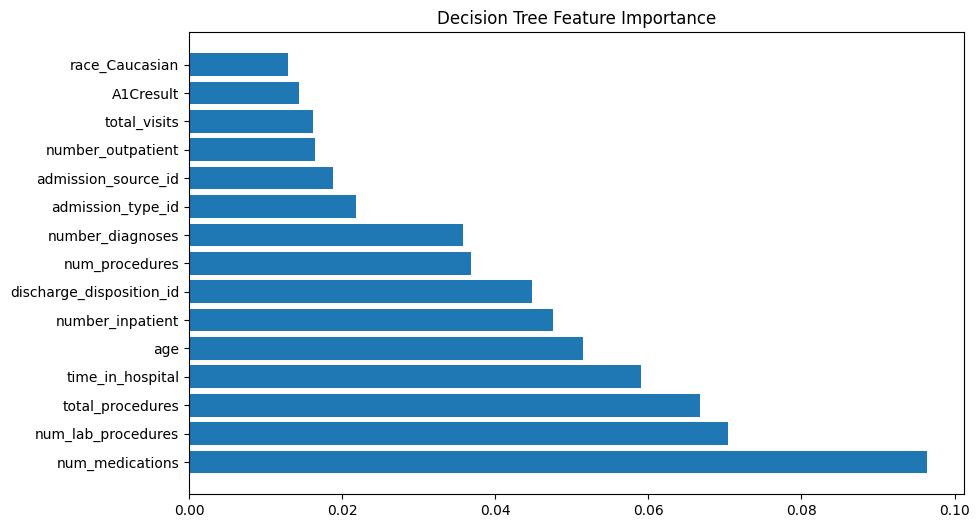

In [ ]:
top_features = dt_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Decision Tree Feature Importance")

plt.show()

2. Random Forest

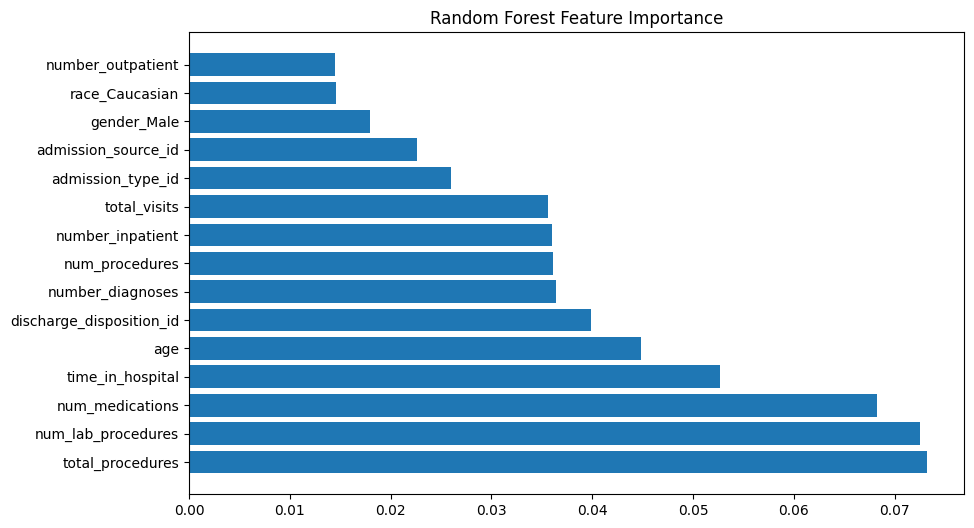

In [ ]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Random Forest Feature Importance")

plt.show()

3. XGBoost

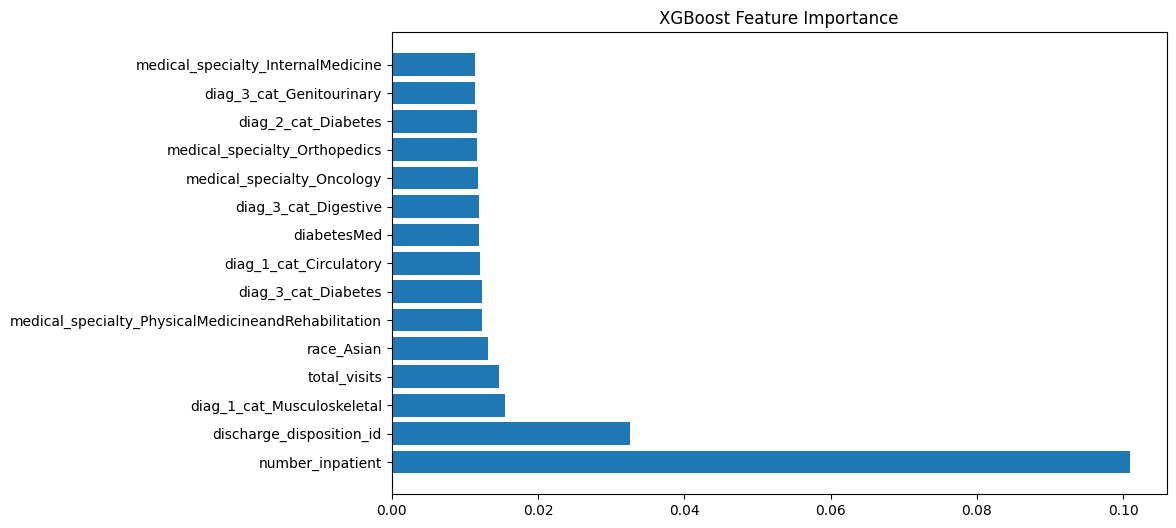

In [ ]:
top_features = xgb_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("XGBoost Feature Importance")

plt.show()

In [ ]:
comparison = pd.merge(
    lr_importance[['Feature','Absolute_Coefficient']],
    dt_importance[['Feature','Importance']],
    on='Feature',
    how='outer'
)

comparison = comparison.merge(
    importance[['Feature','Importance']],
    on='Feature',
    how='outer',
    suffixes=('_DT','_RF')
)

comparison = comparison.merge(
    xgb_importance[['Feature','Importance']],
    on='Feature',
    how='outer'
)

comparison.columns = [
    'Feature',
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

comparison = comparison.sort_values(
    by='Random Forest',
    ascending=False
)

print(comparison.head(20))

                       Feature  Logistic Regression  Decision Tree  \
165           total_procedures             0.000560       0.066709   
141         num_lab_procedures             0.004411       0.070385   
142            num_medications             0.060297       0.096421   
161           time_in_hospital             0.052532       0.059045   
7                          age             0.003758       0.051433   
37    discharge_disposition_id             0.024647       0.044845   
144           number_diagnoses             0.044894       0.035749   
143             num_procedures             0.044364       0.036867   
146           number_inpatient             0.288122       0.047541   
166               total_visits             0.122076       0.016209   
6            admission_type_id             0.007160       0.021779   
5          admission_source_id             0.003513       0.018771   
38                 gender_Male             0.012839       0.012953   
152             race

# **Saving the Model**

In [ ]:
import joblib
import os

# Create the models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained pipeline
joblib.dump(lr_pipeline, "models/final_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
print(X.shape)

(101763, 168)


In [ ]:
print(X.columns)

Index(['age', 'admission_type_id', 'discharge_disposition_id',
       'admission_source_id', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency',
       ...
       'insulin_No', 'insulin_Steady', 'insulin_Up', 'glyburide-metformin_No',
       'glyburide-metformin_Steady', 'glyburide-metformin_Up',
       'glipizide-metformin_Steady', 'glimepiride-pioglitazone_Steady',
       'metformin-rosiglitazone_Steady', 'metformin-pioglitazone_Steady'],
      dtype='object', length=168)


In [ ]:
print(X.columns.tolist()[:15])

['age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'change']


**The original target variable readmitted contained three categories (NO, >30, <30). For this study, the problem was transformed into a binary classification task by mapping <30 to class 1 (high-risk readmission within 30 days) and both NO and >30 to class 0 (not readmitted within 30 days). This formulation aligns with the clinical objective of identifying patients at risk of early readmission.**

#**Uses Binary Classification.**